In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import shutil

source = "../fraudTrain.csv"
destination = "fraudTrain.csv"

shutil.move(source, destination)

In [2]:
df=pd.read_csv("fraudTrain.csv")
df.head()
#df.shape


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [3]:
df.isnull().sum()

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [4]:
df.apply(lambda x:x.unique().shape[0])

Unnamed: 0               1296675
trans_date_trans_time    1274791
cc_num                       983
merchant                     693
category                      14
amt                        52928
first                        352
last                         481
gender                         2
street                       983
city                         894
state                         51
zip                          970
lat                          968
long                         969
city_pop                     879
job                          494
dob                          968
trans_num                1296675
unix_time                1274823
merch_lat                1247805
merch_long               1275745
is_fraud                       2
dtype: int64

In [5]:
df.shape

(1296675, 23)

In [6]:
df["state"].unique()

array(['NC', 'WA', 'ID', 'MT', 'VA', 'PA', 'KS', 'TN', 'IA', 'WV', 'FL',
       'CA', 'NM', 'NJ', 'OK', 'IN', 'MA', 'TX', 'WI', 'MI', 'WY', 'HI',
       'NE', 'OR', 'LA', 'DC', 'KY', 'NY', 'MS', 'UT', 'AL', 'AR', 'MD',
       'GA', 'ME', 'AZ', 'MN', 'OH', 'CO', 'VT', 'MO', 'SC', 'NV', 'IL',
       'NH', 'SD', 'AK', 'ND', 'CT', 'RI', 'DE'], dtype=object)

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df["street"].nunique()

983

In [9]:
df["is_fraud"].value_counts()

is_fraud
0    1289169
1       7506
Name: count, dtype: int64

In [10]:
data=df.copy()
data["trans_date_trans_time"]=pd.to_datetime(data["trans_date_trans_time"])
data["hour"]=data["trans_date_trans_time"].dt.hour
data["is_night"]=data["hour"].apply(lambda x: 1 if x>=22 or x<=5 else 0)
data["date"]=data["trans_date_trans_time"].dt.dayofweek

In [11]:
data.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,hour,is_night,date
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,0,1,1
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,0,1,1
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,0,1,1
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,0,1,1
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,0,1,1


In [12]:
data.drop(columns=["Unnamed: 0","first","last","street","zip","trans_num","dob","job"],axis=1,inplace=True)

In [13]:
data.head()

,trans_date_trans_time,cc_num,merchant,category,amt,gender,city,state,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud,hour,is_night,date
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,Moravian Falls,NC,36.0788,-81.1781,3495,1325376018,36.011293,-82.048315,0,0,1,1
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,Orient,WA,48.8878,-118.2105,149,1325376044,49.159047,-118.186462,0,0,1,1
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,M,Malad City,ID,42.1808,-112.2620,4154,1325376051,43.150704,-112.154481,0,0,1,1
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,Boulder,MT,46.2306,-112.1138,1939,1325376076,47.034331,-112.561071,0,0,1,1
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,M,Doe Hill,VA,38.4207,-79.4629,99,1325376186,38.674999,-78.632459,0,0,1,1


In [14]:
data["amt"].skew()

np.float64(42.2778737900512)

<Axes: >

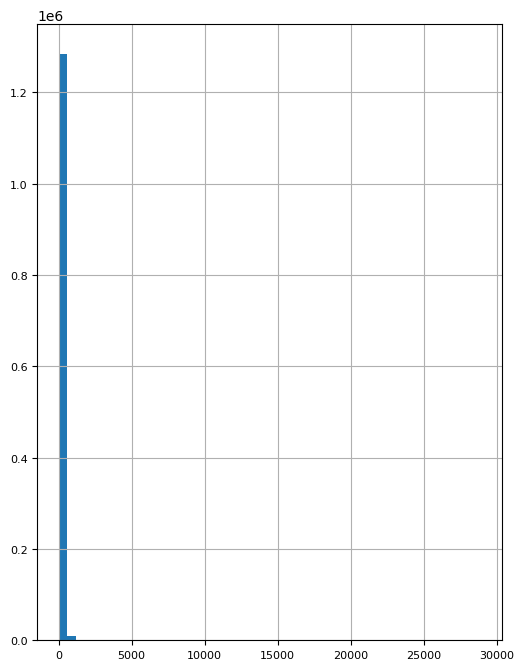

In [15]:
sk_df=data.copy()
ak=sk_df["amt"].hist(figsize=(6,8),bins=50,xlabelsize=8,ylabelsize=8)
ak

In [16]:
data["log_amount"]=np.log1p(df["amt"])

In [17]:
data.head()

,trans_date_trans_time,cc_num,merchant,category,amt,gender,city,state,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud,hour,is_night,date,log_amount
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,Moravian Falls,NC,36.0788,-81.1781,3495,1325376018,36.011293,-82.048315,0,0,1,1,1.786747
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,Orient,WA,48.8878,-118.2105,149,1325376044,49.159047,-118.186462,0,0,1,1,4.684259
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,M,Malad City,ID,42.1808,-112.2620,4154,1325376051,43.150704,-112.154481,0,0,1,1,5.398660
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,Boulder,MT,46.2306,-112.1138,1939,1325376076,47.034331,-112.561071,0,0,1,1,3.828641
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,M,Doe Hill,VA,38.4207,-79.4629,99,1325376186,38.674999,-78.632459,0,0,1,1,3.760269


In [18]:
threshold=data["amt"].quantile(0.95)
data["high_amt"]=data["amt"].apply(lambda x:1 if x>threshold else 0)
data.head()

,trans_date_trans_time,cc_num,merchant,category,amt,gender,city,state,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud,hour,is_night,date,log_amount,high_amt
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,Moravian Falls,NC,36.0788,-81.1781,3495,1325376018,36.011293,-82.048315,0,0,1,1,1.786747,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,Orient,WA,48.8878,-118.2105,149,1325376044,49.159047,-118.186462,0,0,1,1,4.684259,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,M,Malad City,ID,42.1808,-112.2620,4154,1325376051,43.150704,-112.154481,0,0,1,1,5.398660,1
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,Boulder,MT,46.2306,-112.1138,1939,1325376076,47.034331,-112.561071,0,0,1,1,3.828641,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,M,Doe Hill,VA,38.4207,-79.4629,99,1325376186,38.674999,-78.632459,0,0,1,1,3.760269,0


In [19]:
data["user_avg_amt"]=data.groupby("cc_num")["amt"].transform("mean")
data["deviation_amt"]=data["amt"]-data["user_avg_amt"]
data["spending_ratio"]=data["amt"]/data["user_avg_amt"]

In [20]:
data=data.sort_values(["cc_num","trans_date_trans_time"])
data=data.set_index("trans_date_trans_time")
data["last_1h_trans"]=data.groupby("cc_num")["cc_num"].rolling("1h").count().reset_index(level=0,drop=True)
data=data.reset_index()

In [21]:
data.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'gender', 'city', 'state', 'lat', 'long', 'city_pop', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud', 'hour', 'is_night', 'date',
       'log_amount', 'high_amt', 'user_avg_amt', 'deviation_amt',
       'spending_ratio', 'last_1h_trans'],
      dtype='object')

In [22]:
data.head()

,trans_date_trans_time,cc_num,merchant,category,amt,gender,city,state,lat,long,...,is_fraud,hour,is_night,date,log_amount,high_amt,user_avg_amt,deviation_amt,spending_ratio,last_1h_trans
0,2019-01-01 12:47:15,60416207185,"fraud_Jones, Sawayn and Romaguera",misc_net,7.27,F,Fort Washakie,WY,43.0048,-108.8964,...,0,12,0,1,2.112635,0,56.023366,-48.753366,0.129767,1.0
1,2019-01-02 08:44:57,60416207185,fraud_Berge LLC,gas_transport,52.94,F,Fort Washakie,WY,43.0048,-108.8964,...,0,8,0,2,3.987872,0,56.023366,-3.083366,0.944963,1.0
2,2019-01-02 08:47:36,60416207185,fraud_Luettgen PLC,gas_transport,82.08,F,Fort Washakie,WY,43.0048,-108.8964,...,0,8,0,2,4.419804,0,56.023366,26.056634,1.465103,2.0
3,2019-01-02 12:38:14,60416207185,fraud_Daugherty LLC,kids_pets,34.79,F,Fort Washakie,WY,43.0048,-108.8964,...,0,12,0,2,3.577669,0,56.023366,-21.233366,0.620991,1.0
4,2019-01-02 13:10:46,60416207185,fraud_Beier and Sons,home,27.18,F,Fort Washakie,WY,43.0048,-108.8964,...,0,13,0,2,3.338613,0,56.023366,-28.843366,0.485155,2.0


In [23]:
data["log_amount"].skew()

np.float64(-0.29885281578522954)

In [24]:
from sklearn.preprocessing import OneHotEncoder
encoder=OneHotEncoder(drop="first",sparse_output=False)
encoded=encoder.fit_transform(data[["gender"]])

encoded_df=pd.DataFrame(encoded,columns=encoder.get_feature_names_out(["gender"]),index=data.index)
data=pd.concat([data,encoded_df],axis=1)
#print(final_data)

In [25]:
data.head()

,trans_date_trans_time,cc_num,merchant,category,amt,gender,city,state,lat,long,...,hour,is_night,date,log_amount,high_amt,user_avg_amt,deviation_amt,spending_ratio,last_1h_trans,gender_M
0,2019-01-01 12:47:15,60416207185,"fraud_Jones, Sawayn and Romaguera",misc_net,7.27,F,Fort Washakie,WY,43.0048,-108.8964,...,12,0,1,2.112635,0,56.023366,-48.753366,0.129767,1.0,0.0
1,2019-01-02 08:44:57,60416207185,fraud_Berge LLC,gas_transport,52.94,F,Fort Washakie,WY,43.0048,-108.8964,...,8,0,2,3.987872,0,56.023366,-3.083366,0.944963,1.0,0.0
2,2019-01-02 08:47:36,60416207185,fraud_Luettgen PLC,gas_transport,82.08,F,Fort Washakie,WY,43.0048,-108.8964,...,8,0,2,4.419804,0,56.023366,26.056634,1.465103,2.0,0.0
3,2019-01-02 12:38:14,60416207185,fraud_Daugherty LLC,kids_pets,34.79,F,Fort Washakie,WY,43.0048,-108.8964,...,12,0,2,3.577669,0,56.023366,-21.233366,0.620991,1.0,0.0
4,2019-01-02 13:10:46,60416207185,fraud_Beier and Sons,home,27.18,F,Fort Washakie,WY,43.0048,-108.8964,...,13,0,2,3.338613,0,56.023366,-28.843366,0.485155,2.0,0.0


In [30]:
!pip install geopy
from geopy.distance import geodesic

data["distance"] = df.apply(
    lambda row: geodesic(
        (row["lat"], row["long"]),
        (row["merch_lat"], row["merch_long"])
    ).km,
    axis=1
)

^C


KeyboardInterrupt: 

In [26]:
import numpy as np

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return R * c

data["distance"] = haversine(
    data["lat"],
    data["long"],
    data["merch_lat"],
    data["merch_long"]
)

In [27]:
data.head()

,trans_date_trans_time,cc_num,merchant,category,amt,gender,city,state,lat,long,...,is_night,date,log_amount,high_amt,user_avg_amt,deviation_amt,spending_ratio,last_1h_trans,gender_M,distance
0,2019-01-01 12:47:15,60416207185,"fraud_Jones, Sawayn and Romaguera",misc_net,7.27,F,Fort Washakie,WY,43.0048,-108.8964,...,0,1,2.112635,0,56.023366,-48.753366,0.129767,1.0,0.0,127.606239
1,2019-01-02 08:44:57,60416207185,fraud_Berge LLC,gas_transport,52.94,F,Fort Washakie,WY,43.0048,-108.8964,...,0,2,3.987872,0,56.023366,-3.083366,0.944963,1.0,0.0,110.308921
2,2019-01-02 08:47:36,60416207185,fraud_Luettgen PLC,gas_transport,82.08,F,Fort Washakie,WY,43.0048,-108.8964,...,0,2,4.419804,0,56.023366,26.056634,1.465103,2.0,0.0,21.787261
3,2019-01-02 12:38:14,60416207185,fraud_Daugherty LLC,kids_pets,34.79,F,Fort Washakie,WY,43.0048,-108.8964,...,0,2,3.577669,0,56.023366,-21.233366,0.620991,1.0,0.0,87.204215
4,2019-01-02 13:10:46,60416207185,fraud_Beier and Sons,home,27.18,F,Fort Washakie,WY,43.0048,-108.8964,...,0,2,3.338613,0,56.023366,-28.843366,0.485155,2.0,0.0,74.212965


In [28]:
data.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'gender', 'city', 'state', 'lat', 'long', 'city_pop', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud', 'hour', 'is_night', 'date',
       'log_amount', 'high_amt', 'user_avg_amt', 'deviation_amt',
       'spending_ratio', 'last_1h_trans', 'gender_M', 'distance'],
      dtype='object')

In [29]:
data=data.drop(["trans_date_trans_time","cc_num","gender","lat","long","city_pop","unix_time","merch_lat","merch_long"],axis=1)

In [30]:
from sklearn.model_selection import train_test_split
x=data.drop("is_fraud",axis=1)
y=data["is_fraud"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [31]:
train_data=x_train.copy()
train_data["is_fraud"]=y_train

state_te=train_data.groupby("state")["is_fraud"].mean()
category_te=train_data.groupby("category")["is_fraud"].mean()

x_train["state_te"]=x_train["state"].map(state_te)
x_train["category_te"]=x_train["category"].map(category_te)

x_test["state_te"]=x_test["state"].map(state_te)
x_test["category_te"]=x_test["category"].map(category_te)

global_mean=y_train.mean()

x_test["state_te"]=x_test["state_te"].fillna(global_mean)
x_test["category_te"]=x_test["category_te"].fillna(global_mean)

#x_train=x_train.drop(["state","category"])
#x_test=x_test.drop(["state","category"])

In [32]:
x_train.columns
x_test.columns

Index(['merchant', 'category', 'amt', 'city', 'state', 'hour', 'is_night',
       'date', 'log_amount', 'high_amt', 'user_avg_amt', 'deviation_amt',
       'spending_ratio', 'last_1h_trans', 'gender_M', 'distance', 'state_te',
       'category_te'],
      dtype='object')

In [33]:
x_train=x_train.drop(["state","category","city","merchant"],axis=1)
x_test=x_test.drop(["state","category","city","merchant"],axis=1)

In [34]:
x_train.head()

,amt,hour,is_night,date,log_amount,high_amt,user_avg_amt,deviation_amt,spending_ratio,last_1h_trans,gender_M,distance,state_te,category_te
508811,14.22,12,0,3,2.722610,0,70.674423,-56.454423,0.201204,1.0,0.0,62.567613,0.005530,0.001666
394928,37.87,20,0,0,3.660223,0,59.099882,-21.229882,0.640780,1.0,0.0,60.326607,0.005677,0.002544
536348,52.45,8,0,2,3.978747,0,67.310753,-14.860753,0.779222,1.0,0.0,75.573798,0.006665,0.004731
270569,9.81,19,0,1,2.380472,0,63.187024,-53.377024,0.155253,1.0,0.0,108.450248,0.004860,0.007251
532589,74.26,17,0,1,4.320949,0,90.369521,-16.109521,0.821737,1.0,1.0,44.946517,0.005444,0.001632


In [35]:
x_test.shape

(259335, 14)

In [36]:
x_full=pd.concat([x_train,x_test],axis=0)
y_full=pd.concat([y_train,y_test],axis=0)
full_data=x_full.copy()
full_data["is_fraud"]=y_full
full_data.head()

,amt,hour,is_night,date,log_amount,high_amt,user_avg_amt,deviation_amt,spending_ratio,last_1h_trans,gender_M,distance,state_te,category_te,is_fraud
508811,14.22,12,0,3,2.722610,0,70.674423,-56.454423,0.201204,1.0,0.0,62.567613,0.005530,0.001666,0
394928,37.87,20,0,0,3.660223,0,59.099882,-21.229882,0.640780,1.0,0.0,60.326607,0.005677,0.002544,0
536348,52.45,8,0,2,3.978747,0,67.310753,-14.860753,0.779222,1.0,0.0,75.573798,0.006665,0.004731,0
270569,9.81,19,0,1,2.380472,0,63.187024,-53.377024,0.155253,1.0,0.0,108.450248,0.004860,0.007251,0
532589,74.26,17,0,1,4.320949,0,90.369521,-16.109521,0.821737,1.0,1.0,44.946517,0.005444,0.001632,0


C:\Users\prasa\AppData\Local\Temp\ipykernel_25280\3833390740.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=full_data,x="is_fraud",palette="Blues")


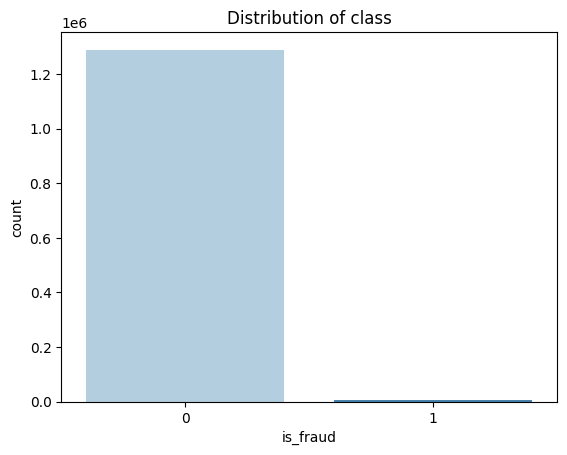

In [43]:

import seaborn as sns
sns.countplot(data=full_data,x="is_fraud",palette="Blues")
plt.xticks(np.arange(2),labels=["0","1"])
plt.title("Distribution of class")
plt.show()

In [44]:

vc = df['is_fraud'].value_counts().to_frame().reset_index()
vc['percent'] = vc["is_fraud"].apply(lambda x : round(100*float(x) / len(df), 2))
vc = vc.rename(columns = {"index" : "Target", "Class" : "Count"})
vc

,is_fraud,count,percent
0,0,1289169,0.0
1,1,7506,0.0


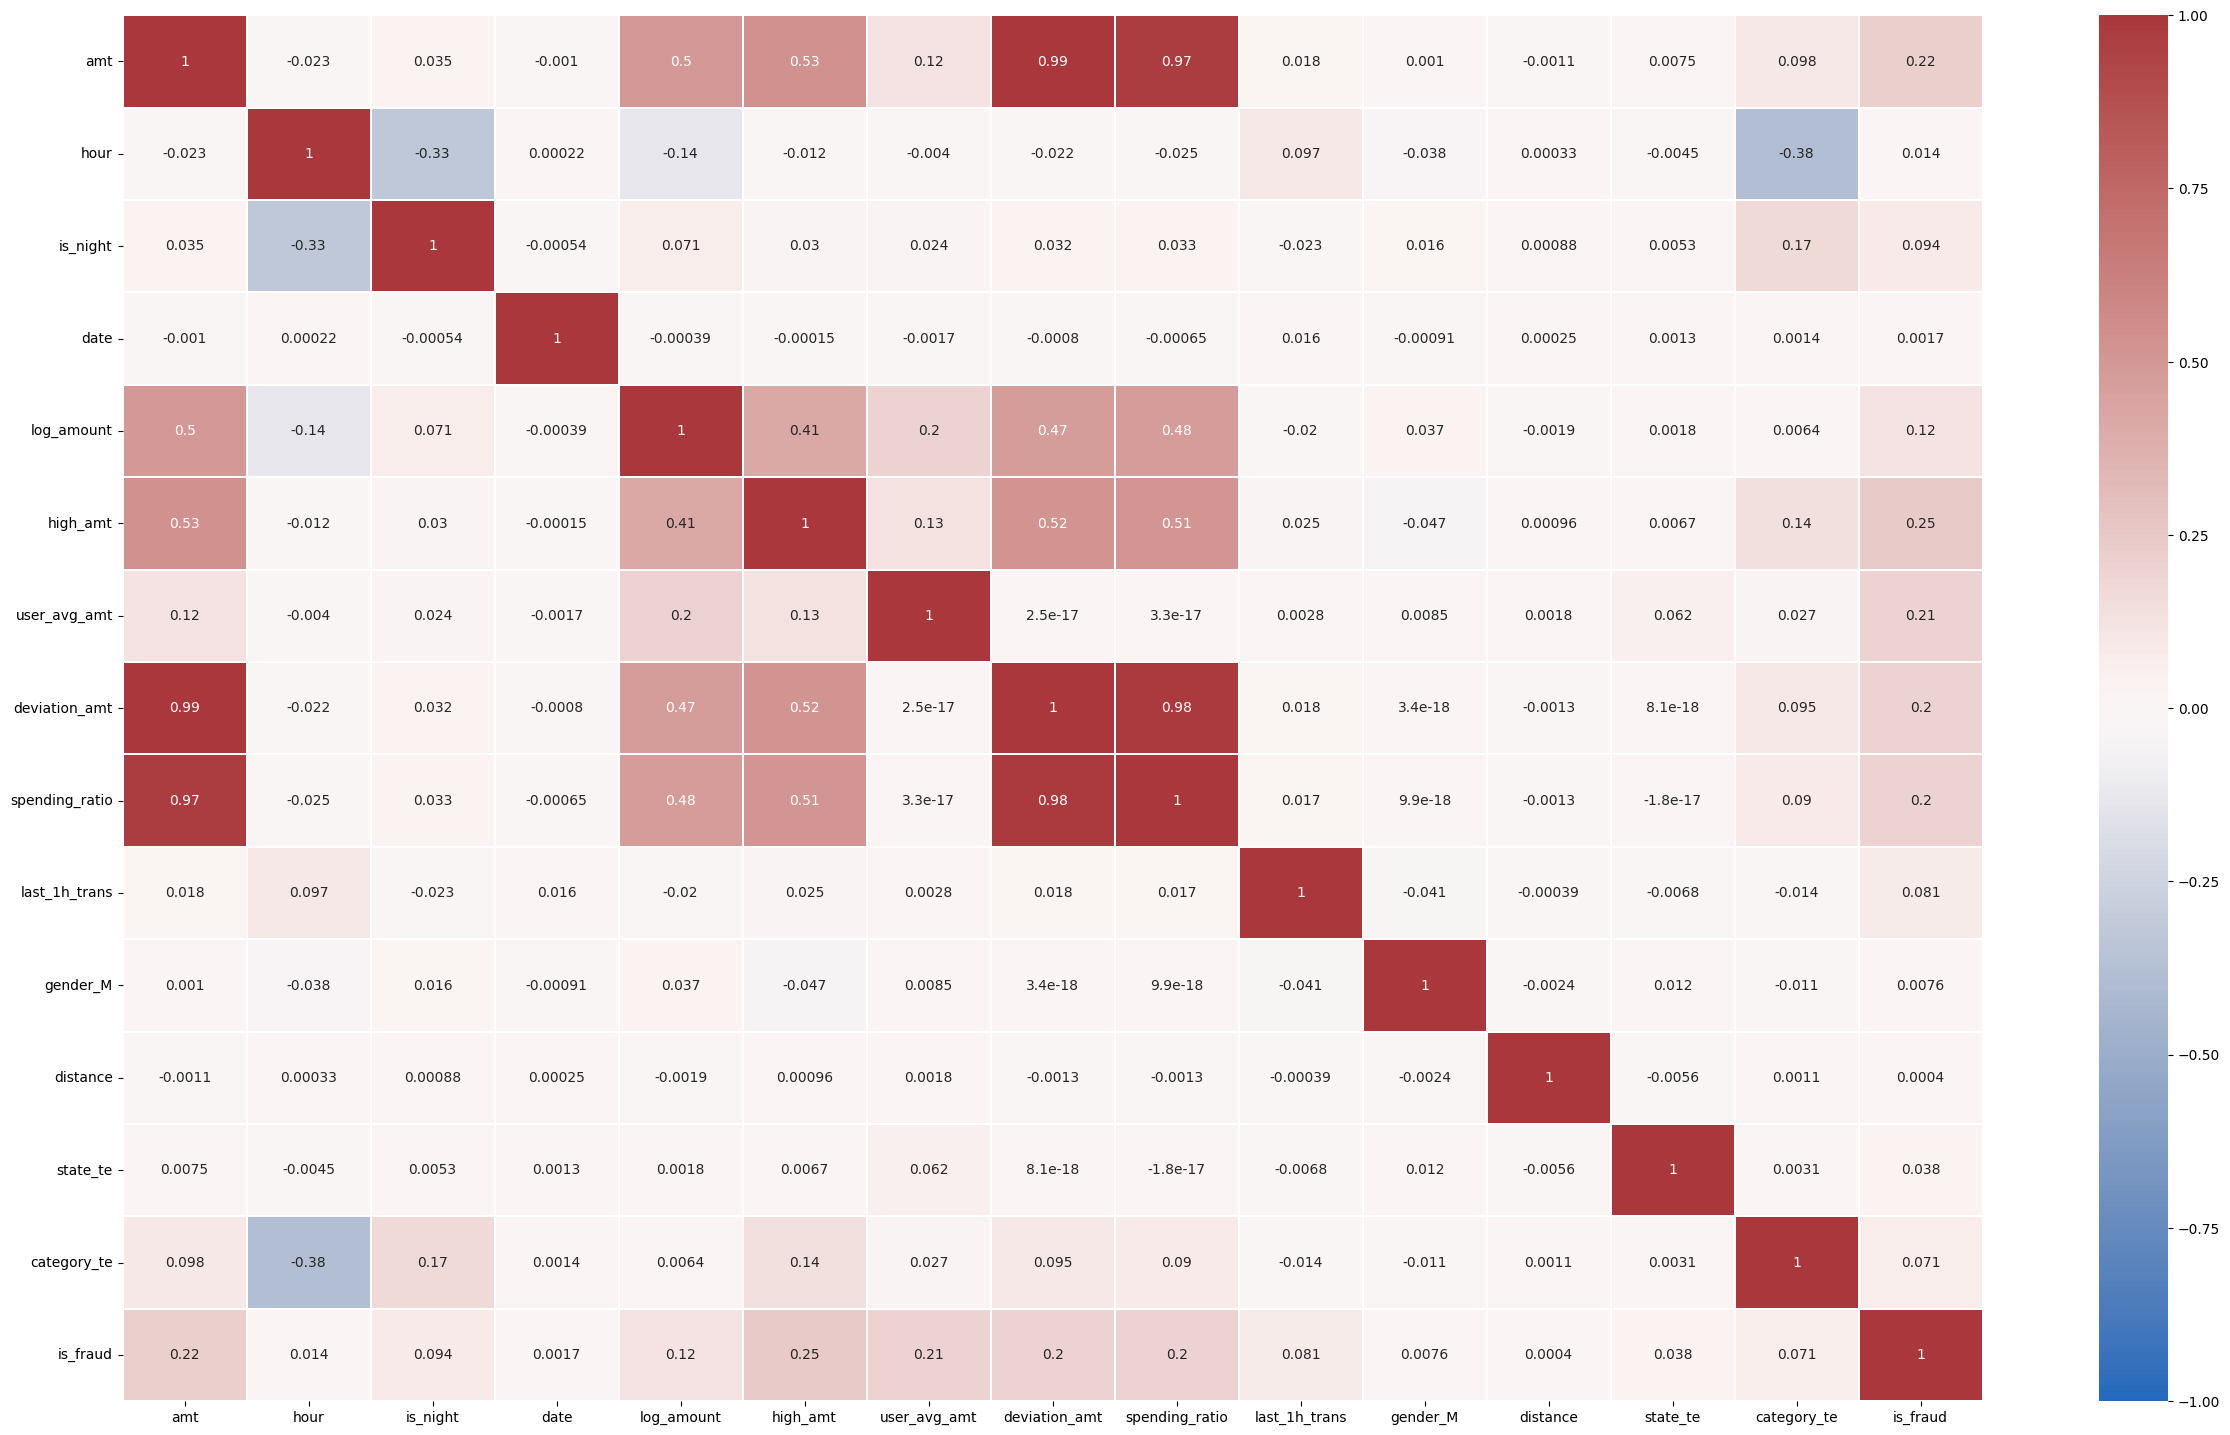

In [45]:
plt.figure(figsize=(30,18))
corr=full_data.corr()
ax=sns.heatmap(corr,cmap='vlag',vmax=1.0,vmin=-1.0,annot=True,annot_kws={'size':10},linewidth=0.1,square=False)

In [45]:
full_data.corr()["is_fraud"].sort_values(ascending=False)

is_fraud          1.000000
high_amt          0.248622
amt               0.219404
user_avg_amt      0.209960
spending_ratio    0.196145
deviation_amt     0.195421
log_amount        0.120439
is_night          0.093547
last_1h_trans     0.080751
category_te       0.070719
state_te          0.037827
hour              0.013799
gender_M          0.007642
date              0.001739
distance          0.000403
Name: is_fraud, dtype: float64

In [50]:
!pip install shap

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

from imblearn.over_sampling import SMOTE
np.random.seed(42)

In [38]:
x_train.columns

Index(['amt', 'hour', 'is_night', 'date', 'log_amount', 'high_amt',
       'user_avg_amt', 'deviation_amt', 'spending_ratio', 'last_1h_trans',
       'gender_M', 'distance', 'state_te', 'category_te'],
      dtype='object')

In [53]:
x,y=full_data.iloc[:,:-1],full_data.iloc[:,-1]
print(x.shape,y.shape)

ct=ColumnTransformer([("someone",StandardScaler(),[0,-1])],remainder='passthrough')
x_train=ct.fit_transform(x_train)
x_test=ct.transform(x_test)

train_labels,train_label_counts=np.unique(y_train,return_counts=True)
test_labels,test_label_counts=np.unique(y_test,return_counts=True)

print("\\label distribution")
print(f"labels:{train_labels}")
print(f"train set --label counts:{train_label_counts},label_percentage:{train_label_counts/len(y_train)}")
print(f'Test set  --> label counts: {test_label_counts}   label percentages: {test_label_counts/ len(y_test)}')

# Saving as csv files
X_train = pd.DataFrame(data=x_train, columns=x.columns)
X_test = pd.DataFrame(data=x_test, columns=x.columns)
y_train = pd.DataFrame(data=y_train, columns=[y.name])
y_test = pd.DataFrame(data=y_test, columns=[y.name])

X_train.to_csv('project/X_train.csv', index=False)
X_test.to_csv('project/X_test.csv', index=False)
y_train.to_csv('project/y_train.csv', index=False)
y_test.to_csv('project/y_test.csv', index=False)

(1296675, 14) (1296675,)
\label distribution
labels:[0 1]
train set --label counts:[1031335    6005],label_percentage:[0.99421116 0.00578884]
Test set  --> label counts: [257834   1501]   label percentages: [0.99421212 0.00578788]


OSError: Cannot save file into a non-existent directory: 'project'

In [ ]:
x,y=full_data.iloc[:,:-1],full_data.iloc[:,-1]
print(x.shape,y.shape)
n_success_class=full_data["is_fraud"].value_counts()[1]

data_success=full_data[full_data["is_fraud"]==1]
data_alternator=full_data[full_data["is_fraud"]==0]

data_success=data_success.reset_index(drop=True)
data_alternator=data_alternator.reset_index(drop=True)

indices=np.random.choice(data_success.shape[0],size=n_success_class//2,replace=False)
data_success_50=data_success.iloc[indices]
data_success_rest=data_success.drop(data_success.index[indices])

#class 0
indices=np.random.choice(data_alternator.shape[0],size=n_success_class//2)
data_alternator_50=data_alternator.iloc[indices]
data_alternator_rest=data_alternator.drop(data_alternator.index[indices])

train_data=pd.concat([data_success_50,data_alternator_50])
test_data=pd.concat([data_success_rest,data_alternator_rest])

x_train_os,y_train_os=train_data.iloc[:,:-1],train_data.iloc[:,-1]
x_test_os,y_test_os=test_data.iloc[:,:-1],test_data.iloc[:,-1]

ct=ColumnTransformer([('Somename',StandardScaler(),[0,-1])],remainder='passthrough')
ct.fit(x_train_os)
x_train_os=ct.transform(x_train_os)
x_test_os=ct.transform(x_test_os)


train_labels,train_label_counts=np.unique(y_train_os,return_counts=True)
train_labels,train_label_counts=np.unique(y_test_os,return_counts=True)

print("\\label distribution")
print(f"labels:{train_labels}")
print(f"train set --label counts:{train_label_counts},label_percentage:{train_label_counts/len(y_train)}")
print(f'Test set  --> label counts: {test_label_counts}   label percentages: {test_label_counts/ len(y_test)}')

# Saving as csv files
X_train_os = pd.DataFrame(data=x_train_os, columns=x.columns)
X_test_os = pd.DataFrame(data=x_test_os, columns=x.columns)
y_train_os = pd.DataFrame(data=y_train_os, columns=[y.name])
y_test_os= pd.DataFrame(data=y_test_os, columns=[y.name])

X_train_os.to_csv('project/X_train_os.csv', index=False)
X_test_os.to_csv('project/X_test_os.csv', index=False)
y_train_os.to_csv('project/y_train_os.csv', index=False)
y_test_os.to_csv('project/y_test_os.csv', index=False)





In [54]:
x,y=full_data.iloc[:,:-1],full_data.iloc[:,-1]

x_train_smote,x_test_smote,y_train_smote,y_test_smote=train_test_split(x,y,test_size=0.20,random_state=23,stratify=y)
print(f'x_train_smote:{x_train_smote.shape},y_train_smote:{y_train_smote.shape},x_test_smote:{x_test_smote.shape},y_test_smote:{y_test_smote.shape}')

print(f'\ntrain labels:\n{y_train_smote.value_counts()}')
# scaling `amount` and `time`
ct = ColumnTransformer([('somename', StandardScaler(), [0,-1])], remainder='passthrough')
ct.fit(x_train_smote)
x_train_smote = ct.transform(x_train_smote)
x_test_smote = ct.transform(x_test_smote)


smote=SMOTE(random_state=23)
x_train_smote,y_train_smote=smote.fit_resample(x_train_smote,y_train_smote)

train_labels, train_label_counts = np.unique(y_train_smote, return_counts=True)
test_labels, test_label_counts = np.unique(y_test_smote, return_counts=True)

print('\nLabel Distributions:')
print(f'lables: {train_labels}')
print(f'Train set --> label counts: {train_label_counts} label percentages: {train_label_counts/ len(y_train_smote)}')
print(f'Test set  --> label counts: {test_label_counts}   label percentages: {test_label_counts/ len(y_test_smote)}')

# Saving as csv files
'''x_train_smote = pd.DataFrame(data=x_train_smote, columns=x.columns)
x_test_smote = pd.DataFrame(data=x_test_smote, columns=x.columns)
y_train_smote = pd.DataFrame(data=y_train_smote, columns=[y.name])
y_test_smote = pd.DataFrame(data=y_test_smote, columns=[y.name])

x_train_smote.to_csv('project/x_train_smote.csv', sep=',', index=False)
x_test_smote.to_csv('project/x_test_smote.csv', sep=',', index=False)
y_train_smote.to_csv('project/y_train_smote.csv',sep=',', index = False)
y_test_smote.to_csv('project/y_test_smote.csv', sep=',', index = False)'''

x_train_smote:(1037340, 14),y_train_smote:(1037340,),x_test_smote:(259335, 14),y_test_smote:(259335,)

train labels:
is_fraud
0    1031335
1       6005
Name: count, dtype: int64

Label Distributions:
lables: [0 1]
Train set --> label counts: [1031335 1031335] label percentages: [0.5 0.5]
Test set  --> label counts: [257834   1501]   label percentages: [0.99421212 0.00578788]


"x_train_smote = pd.DataFrame(data=x_train_smote, columns=x.columns)\nx_test_smote = pd.DataFrame(data=x_test_smote, columns=x.columns)\ny_train_smote = pd.DataFrame(data=y_train_smote, columns=[y.name])\ny_test_smote = pd.DataFrame(data=y_test_smote, columns=[y.name])\n\nx_train_smote.to_csv('project/x_train_smote.csv', sep=',', index=False)\nx_test_smote.to_csv('project/x_test_smote.csv', sep=',', index=False)\ny_train_smote.to_csv('project/y_train_smote.csv',sep=',', index = False)\ny_test_smote.to_csv('project/y_test_smote.csv', sep=',', index = False)"

In [ ]:
full_data.head()

In [39]:
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

from sklearn.ensemble import RandomForestClassifier,IsolationForest


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, make_scorer
from sklearn.metrics import auc, roc_curve, average_precision_score, PrecisionRecallDisplay #plot_precision_recall_curve
from imblearn.metrics import classification_report_imbalanced
np.random.seed(42)

In [41]:
#statiffied  sampling
X_train_strat = pd.read_csv('x_train.csv')
X_test_strat = pd.read_csv('x_test.csv')
y_train_strat = pd.read_csv('y_train.csv')
y_test_strat = pd.read_csv('y_test.csv')

# Over Sampling
X_train_os = pd.read_csv('x_train_os.csv')
X_test_os = pd.read_csv('x_test_os.csv')
y_train_os = pd.read_csv('y_train_os.csv')
y_test_os = pd.read_csv('y_test_os.csv')

# Over Sampling with SMOTE
X_train_smote = pd.read_csv('x_train_smote.csv')
X_test_smote = pd.read_csv('x_test_smote.csv')
y_train_smote = pd.read_csv('y_train_smote.csv')
y_test_smote = pd.read_csv('y_test_smote.csv')

In [60]:
#Logistic Regression
logreg1=LogisticRegression(max_iter=10000)
clf1=logreg1.fit(X_train_strat,y_train_strat["is_fraud"])
pred1=clf1.predict(X_test_strat)

y_score1=clf1.predict_proba(X_test_strat)[:,-1]

print(f"confusion matrix:{confusion_matrix(y_test_strat,pred1)}")
print(classification_report(y_test_strat,pred1))

confusion matrix:[[257765     69]
 [  1137    364]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.84      0.24      0.38      1501

    accuracy                           1.00    259335
   macro avg       0.92      0.62      0.69    259335
weighted avg       0.99      1.00      0.99    259335



In [61]:
logreg2=LogisticRegression(max_iter=10000)
clf2=logreg2.fit(X_train_os,y_train_os["is_fraud"])
pred2=clf2.predict(X_test_os)

y_score2=clf2.predict_proba(X_test_os)[:,-1]
print(f"confusion_matrix:{confusion_matrix(y_test_os,pred2)}")
print(classification_report(y_test_os,pred2))

confusion_matrix:[[1183077  102345]
 [    503    3250]]
              precision    recall  f1-score   support

           0       1.00      0.92      0.96   1285422
           1       0.03      0.87      0.06      3753

    accuracy                           0.92   1289175
   macro avg       0.52      0.89      0.51   1289175
weighted avg       1.00      0.92      0.96   1289175



In [63]:
logreg3=LogisticRegression(max_iter=1000)
clf3=logreg3.fit(X_train_smote,y_train_smote["is_fraud"])
pred3=clf3.predict(X_test_smote)

y_score3=clf3.predict_proba(X_test_smote)[:,-1]

print(f"confusion_matrix:{confusion_matrix(y_test_smote,pred3)}")
print(classification_report(y_test_smote,pred3))

confusion_matrix:[[236423  21411]
 [   207   1294]]
              precision    recall  f1-score   support

           0       1.00      0.92      0.96    257834
           1       0.06      0.86      0.11      1501

    accuracy                           0.92    259335
   macro avg       0.53      0.89      0.53    259335
weighted avg       0.99      0.92      0.95    259335



In [64]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 619.8 kB/s eta 0:02:44
   ---------------------------------------- 0.8/101.7 MB 733.0 kB/s eta 0:02:18
   ---------------------------------------- 0.8/101.7 MB 733.0 kB/s eta 0:02:18
   ---------------------------------------- 1.0/101.7 MB 671.1 kB/s eta 0:02:30
   ---------------------------------------- 1.0/101.7 MB 671.1 kB/s eta 0:02:30
   ---------------------------------------- 1.0/101.7 MB 671.1 kB/s eta 0:02:30
    --------------------------------------- 1.3/101.7 MB 639.6 kB/s eta 0:02:37
    --------------------------------------- 1.6/101.7 MB 697.7 kB/s eta 0:02:24
    -

In [64]:
from xgboost import XGBClassifier
model1=XGBClassifier()
clf1=model1.fit(X_train_strat,y_train_strat["is_fraud"])
pred1=clf1.predict(X_test_strat)
y_score1=clf1.predict_proba(X_test_strat)[:,-1]

print(f"confusion_matrix:{confusion_matrix(y_test_strat,pred1)}")
print(classification_report(y_test_strat,pred1))

confusion_matrix:[[257691    143]
 [   311   1190]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.89      0.79      0.84      1501

    accuracy                           1.00    259335
   macro avg       0.95      0.90      0.92    259335
weighted avg       1.00      1.00      1.00    259335



In [66]:
from xgboost import XGBClassifier
model2=XGBClassifier()
clf2=model2.fit(X_train_os,y_train_os["is_fraud"])
pred2=clf2.predict(X_test_os)
y_score2=clf1.predict_proba(X_test_os)[:,-1]

print(f"confusion_matrix:{confusion_matrix(y_test_os,pred2)}")
print(classification_report(y_test_os,pred2))

confusion_matrix:[[1248246   37176]
 [    106    3647]]
              precision    recall  f1-score   support

           0       1.00      0.97      0.99   1285422
           1       0.09      0.97      0.16      3753

    accuracy                           0.97   1289175
   macro avg       0.54      0.97      0.57   1289175
weighted avg       1.00      0.97      0.98   1289175



In [48]:
from xgboost import XGBClassifier
model3=XGBClassifier()
clf3=model3.fit(X_train_smote,y_train_smote)
pred3=clf3.predict(X_test_smote)
y_score31=clf3.predict_proba(x_test)[:,-1]

print(f"confusion_matrix:{confusion_matrix(y_test_smote,pred3)}")
print(classification_report(y_test_smote,pred3))

confusion_matrix:[[257674    160]
 [   274   1227]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.88      0.82      0.85      1501

    accuracy                           1.00    259335
   macro avg       0.94      0.91      0.92    259335
weighted avg       1.00      1.00      1.00    259335



In [73]:
print(type(y_train_smote))

<class 'pandas.core.frame.DataFrame'>


In [70]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.mixture import GaussianMixture


In [71]:
x,y=full_data.iloc[:,:-1],full_data.iloc[:,-1]
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.30,random_state=23)


ct=ColumnTransformer([("somename",StandardScaler(),[0,-1])],remainder="passthrough")

X_train=ct.fit_transform(X_train)
X_test=ct.transform(X_test)

In [69]:
full_data.shape

(1296675, 15)

In [76]:
outlier_function=len(df[df["is_fraud"]==1])/float(len(df[df["is_fraud"]==0]))
isolation_model=IsolationForest( n_estimators=120,
    contamination=outlier_function,   # real fraud ratio
    random_state=23,
    max_samples=256,
    max_features=0.6,
    bootstrap=True
                               )

isolation_model.fit(X_train)


y_pred=isolation_model.predict(X_test)

y_pred=[1 if i==-1 else 0 for i in y_pred]

print(f"confusion Matrix,{confusion_matrix(y_test,y_pred)}")
print(classification_report(y_test,y_pred))

#this is my final model pickel

confusion Matrix,[[385366   1395]
 [  1415    827]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    386761
           1       0.37      0.37      0.37      2242

    accuracy                           0.99    389003
   macro avg       0.68      0.68      0.68    389003
weighted avg       0.99      0.99      0.99    389003



In [43]:
#roc_auc score of xgboost using smote

from sklearn.metrics import roc_auc_score

auc=roc_auc_score(y_test,y_score31)
print("ROC_AUC:",auc)

ROC_AUC: 0.8445593066229594


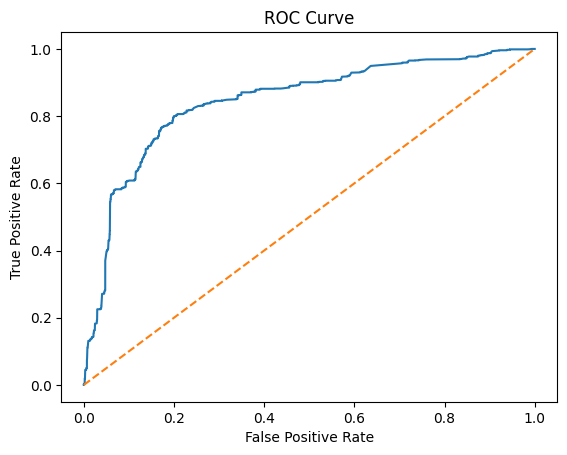

In [44]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_score31)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [40]:
full_data.to_csv("full_data.csv",index=False)

In [54]:
full_data.columns

Index(['amt', 'hour', 'is_night', 'date', 'log_amount', 'high_amt',
       'user_avg_amt', 'deviation_amt', 'spending_ratio', 'last_1h_trans',
       'gender_M', 'distance', 'state_te', 'category_te', 'is_fraud'],
      dtype='object')

In [51]:
from sklearn.metrics import classification_report, roc_auc_score

train_pred = clf3.predict(X_train_smote)
test_pred = clf3.predict(X_test_smote)

print("TRAIN PERFORMANCE")
print(classification_report(y_train_smote, train_pred))

print("TEST PERFORMANCE")
print(classification_report(y_test_smote, test_pred))

TRAIN PERFORMANCE
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1031335
           1       1.00      1.00      1.00   1031335

    accuracy                           1.00   2062670
   macro avg       1.00      1.00      1.00   2062670
weighted avg       1.00      1.00      1.00   2062670

TEST PERFORMANCE
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.88      0.82      0.85      1501

    accuracy                           1.00    259335
   macro avg       0.94      0.91      0.92    259335
weighted avg       1.00      1.00      1.00    259335



In [45]:
train_proba = clf3.predict_proba(X_train_smote)[:, 1]
test_proba = clf3.predict_proba(X_test_smote)[:, 1]

print("Train ROC-AUC:", roc_auc_score(y_train_smote, train_proba))
print("Test ROC-AUC:", roc_auc_score(y_test_smote, test_proba))

Train ROC-AUC: 0.9999934685091841
Test ROC-AUC: 0.9977547540943212


In [52]:
from sklearn.metrics import  precision_score, recall_score, f1_score, roc_auc_score

y_pred = clf3.predict(X_test_smote)
y_proba = clf3.predict_proba(x_test)[:, 1]

metrics = {
    "f1_score": f1_score(y_test_smote, y_pred),
    "precision": precision_score(y_test_smote, y_pred),
    "recall": recall_score(y_test_smote, y_pred),
    "roc_auc": roc_auc_score(y_test, y_proba),
}
print(metrics)

{'f1_score': 0.8497229916897507, 'precision': 0.8846431146359048, 'recall': 0.8174550299800133, 'roc_auc': 0.8445593066229594}


In [55]:
import joblib 
joblib.dump({
    "model":clf3,
    "preprocess":ct,
    "feature_columns": x_train.columns.tolist(),
    "state_te":state_te,
    "category_te":category_te,
    "global_mean":global_mean,
     "metrics":metrics},
    "fraud_final_model_complete.pkl")


['fraud_final_model_complete.pkl']

In [57]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'fraudTrain.csv', 'fraud_model_complete.pkl', 'full_data.csv', 'project.ipynb', 'Untitled.ipynb', 'X_test.csv', 'X_test_os.csv', 'x_test_smote.csv', 'X_train.csv', 'X_train_os.csv', 'x_train_smote.csv', 'y_test.csv', 'y_test_os.csv', 'y_test_smote.csv', 'y_train.csv', 'y_train_os.csv', 'y_train_smote.csv']


In [58]:
os.getcwd()

'C:\\Users\\prasa\\pandas\\project'

In [3]:
import joblib
saved=joblib.load("fraud_model_complete.pkl")

model=saved["model"]
preprocessor=saved["preprocess"]
feature_columns=saved["feature_columns"]
state_te=saved["state_te"]
category_te=saved["category_te"]
global_mean=saved["global_mean"]

In [4]:
input_data = {
    "amt": 120,
    "hour": 22,
    "is_night": 1,
    "date": 50000,
    "log_amount": 4.78,
    "high_amt": 0,
    "user_avg_amt": 85,
    "deviation_amt": 35,
    "spending_ratio": 1.4,
    "last_1h_trans": 2,
    "gender": "M",
    "distance": 5.2,
    "state": "TX",
    "category": "grocery"
}

In [14]:
df = pd.DataFrame([input_data])

In [5]:
df["state_te"]=df["state"].map(state_te).fillna(global_mean)
df["category_te"]=df["category"].map(category_te).fillna(global_mean)


In [6]:
df["gender_M"]=1 if df["gender"].iloc[0]=="M" else 0

In [7]:
df=df.drop(["state","category","gender"],axis=1)

In [8]:

df=df.reindex(columns=feature_columns,fill_value=0)

In [12]:
df_scaled=preprocessor.transform(df)
df_scaled=pd.DataFrame(df_scaled,columns=feature_columns)

In [13]:
prediction = model.predict(df_scaled)[0]
probability = model.predict_proba(df_scaled)[0][1]

print("Fraud Prediction:", prediction)
print("Fraud Probability:", probability)

Fraud Prediction: 0
Fraud Probability: 6.9999182e-06


In [56]:
df.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')